# Phase 7 - Model Fine Tuning

In [15]:
#imports

import pandas as pd                                                                                              
import torch                                                                                                     
from torch.utils.data import Dataset, DataLoader                                                                 
from transformers import AutoTokenizer, AutoModelForSequenceClassification  


import nltk                                                                                                      
from nltk.sentiment.vader import SentimentIntensityAnalyzer                                                      
from sklearn.svm import LinearSVC                                                                                
from sklearn.pipeline import Pipeline                                                                            
from sklearn.feature_extraction.text import TfidfVectorizer                                                      
from sklearn.preprocessing import OneHotEncoder                                                                  
from sklearn.compose import ColumnTransformer 


from torch.optim import AdamW                                                                                    
from torch.utils.data import DataLoader                                                                          
from sklearn.metrics import f1_score                                                                             
import itertools                                                                                                 
import copy 

In [ ]:
# Enforce hardware acceleration                                                                                  
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')                                            
print(f"Hardware allocated: {device}")

Hardware allocated: cuda


In [2]:
train_df = pd.read_csv('Augmented_Ground_Truth_714.csv')                                                         
val_df = pd.read_csv('validation_set_400_final.csv')                                                        
test_df = pd.read_csv('test_set_400_final.csv') 

## Label Encoding and Tokenization

In [5]:
# Maps sentiments to strict integers for Cross-Entropy Loss:                                                     
# Positive -> 0, Neutral -> 1, Negative -> 2     
label2id = {'POSITIVE': 0, 'NEUTRAL': 1, 'NEGATIVE': 2}                                                          
id2label = {v: k for k, v in label2id.items()}                                                                   
                                                                                                                    
def encode_labels(df, label_col='ground_truth'):                                                                 
    """Maps string sentiment labels to integers."""                                                              
    df = df.copy()                                                                                               
    df[label_col] = df[label_col].astype(str).str.strip().str.upper()                                            
    df['encoded_label'] = df[label_col].map(label2id)                                                            
    assert df['encoded_label'].isna().sum() == 0, f"Found unmapped labels in {label_col}!"                       
    return df      

In [6]:
train_col = 'ground_truth' if 'ground_truth' in train_df.columns else 'sentiment'                                
val_col = 'ground_truth' if 'ground_truth' in val_df.columns else 'sentiment'                                    
test_col = 'ground_truth' if 'ground_truth' in test_df.columns else 'sentiment'                                  
                                                                                                                    
# 3. Apply the label encoding                                                                                    
train_df = encode_labels(train_df, label_col=train_col)                                                          
val_df   = encode_labels(val_df, label_col=val_col)                                                              
test_df  = encode_labels(test_df, label_col=test_col)                                                            
                                                                                                                    
print(f"Data sizes -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Data sizes -> Train: 714 | Val: 400 | Test: 400


In [8]:
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-base') 

In [ ]:
class ABSADataset(Dataset):                                                                                                                            
    def __init__(self, df, tokenizer, max_length=128):                                                                                                 
        self.encodings = tokenizer(                                                                                                                    
            df['TargetAspect'].tolist(),                                                                                                               
            df['sentence'].tolist(),                                                                                                                   
            truncation=True,                                                                                                                           
            padding=True,                                                                                                                              
            max_length=max_length,                                                                                                                     
            return_tensors='pt'                                                                                                                        
        )                                                                                                                                              
        self.labels = torch.tensor(df['encoded_label'].tolist(), dtype=torch.long)                                                                     
                                                                                                                                                        
    def __len__(self):                                                                                                                                 
        return len(self.labels)                                                                                                                        
                                                                                                                                                        
    def __getitem__(self, idx):                                                                                                                        
        item = {key: val[idx] for key, val in self.encodings.items()}                                                                                  
        item['labels'] = self.labels[idx]                                                                                                              
        return item                                                                                                                                    
                                                                                                                                                        
# convert DataFrames to PyTorch Datasets                                                                                                            
train_dataset = ABSADataset(train_df, tokenizer)                                                                                                       
val_dataset   = ABSADataset(val_df, tokenizer)                                                                                                         
test_dataset  = ABSADataset(test_df, tokenizer)                                                                                                        
print("Data successfully mapped to PyTorch tensors.")      
                                                                                            
#------                                                                                                     
# Step 7.2: Architectural Selection (Load XLM-RoBERTa)    
#---                                                      

                                    
MODEL_NAME = 'xlm-roberta-base'                                                                                                                        
print(f"\nLoading {MODEL_NAME} architecture...")                                                                                                       
                                                                                                                                                        
model = AutoModelForSequenceClassification.from_pretrained(                                                                                            
    MODEL_NAME,                                                                                                                                        
    num_labels=3,                                                                                                                                      
    id2label=id2label,                                                                                                                                 
    label2id=label2id                                                                                                                                  
).to(device)                                                                                                                                           
                                                                                                                                                        
print(f"Architecture successfully loaded onto {device}. Total Params: {sum(p.numel() for p in model.parameters()):,}")

Data successfully mapped to PyTorch tensors.

Loading xlm-roberta-base architecture...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Architecture successfully loaded onto cuda. Total Params: 278,045,955


## Baseline Selection

In [ ]:
 # Initializes VADER, SVM+TF-IDF, and mBERT for benchmarking against XLM-R.

In [11]:
# Vader Lexicon Baseline Setup
def predict_vader(text):                                                                                         
    """Maps VADER compound scores to our strict 0, 1, 2 encoded labels."""                                       
    score = sia.polarity_scores(str(text))['compound']                                                           
    if score >= 0.05: return 0    # POSITIVE                                                                     
    elif score <= -0.05: return 2 # NEGATIVE                                                                     
    else: return 1                # NEUTRAL  

In [12]:
# SVM + TF-IDF Baseline Setup
preprocessor = ColumnTransformer([                                                                               
    ('sentence', TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, lowercase=True), 'sentence'),            
    ('aspect', OneHotEncoder(handle_unknown='ignore'), ['TargetAspect'])                                         
])                                                                                                               
                                                                                                                    
svm_pipeline = Pipeline([                                                                                        
    ('preprocessor', preprocessor),                                                                              
    ('classifier', LinearSVC(C=1.0, class_weight='balanced', random_state=42, max_iter=20000))                   
])  

In [14]:
# mBERT baseline setup

MBERT_NAME = 'bert-base-multilingual-cased'                                                                      
mbert_tokenizer = AutoTokenizer.from_pretrained(MBERT_NAME)                                                      
                                                                                                                

## Hyperparameter Tuning

In [16]:
LR_GRID = [2e-5, 3e-5, 5e-5]                                                                                     
BS_GRID = [16, 32]                                                                                               
EPOCHS = 5                                                                                                       
PATIENCE = 2                                                                                                     
WEIGHT_DECAY = 0.01

In [17]:
def evaluate_model(model, dataloader):                                                                           
    """Calculates Macro-F1 on the Validation Set."""                                                             
    model.eval()                                                                                                 
    preds, trues = [], []                                                                                        
    with torch.no_grad():                                                                                        
        for batch in dataloader:                                                                                 
            input_ids = batch['input_ids'].to(device)                                                            
            attention_mask = batch['attention_mask'].to(device)                                                  
            labels = batch['labels'].to(device)                                                                  
                                                                                                                    
            outputs = model(input_ids, attention_mask=attention_mask)                                            
            preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())                                      
            trues.extend(labels.cpu().numpy())                                                                   
    return f1_score(trues, preds, average='macro', zero_division=0)                                              
                                                                                                                    
# tracking for the best model across all grid runs                                                        
best_xlmr_f1 = 0                                                                                                 
best_xlmr_params = {}                                                                                            
best_xlmr_state = None 

In [18]:
print(f"Starting Grid Search for {MODEL_NAME}...\n")                                                             
                                                                                                                    
for lr, bs in itertools.product(LR_GRID, BS_GRID):                                                               
    print(f"--- Testing LR: {lr}, Batch Size: {bs} ---")                                                         
                                                                                                                    
    # a fresh, blank model for every grid combination to prevent data leakage                   
    model = AutoModelForSequenceClassification.from_pretrained(                                                  
        MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id                                           
    ).to(device)                                                                                                 
                                                                                                                    
    # Setup DataLoaders with the current grid batch size                                                      
    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)                                        
    val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)                                           
                                                                                                                    
    # AdamW Optimizer with strict 0.01 Weight Decay                                                           
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)                                      
                                                                                                                    
    epochs_no_improve = 0                                                                                        
    best_val_f1_this_run = 0                                                                                     
                                                                                                                    
    # Training Loop                                                                                           
    for epoch in range(EPOCHS):                                                                                  
        model.train()                                                                                            
        for batch in train_loader:                                                                               
            optimizer.zero_grad()                                                                                
            outputs = model(                                                                                     
                input_ids=batch['input_ids'].to(device),                                                         
                attention_mask=batch['attention_mask'].to(device),                                               
                labels=batch['labels'].to(device)                                                                
            )                                                                                                    
            outputs.loss.backward()                                                                              
            optimizer.step()                                                                                     
                                                                                                                    
        # Evaluate after epoch                                                                                   
        val_f1 = evaluate_model(model, val_loader)                                                               
        print(f"  Epoch {epoch+1}/{EPOCHS} | Val Macro-F1: {val_f1:.4f}")                                        
                                                                                                                    
        # Early Stopping Check                                                                                
        if val_f1 > best_val_f1_this_run:                                                                        
            best_val_f1_this_run = val_f1                                                                        
            epochs_no_improve = 0                                                                                
                                                                                                                    
            # Check if this beats the global best model                                                          
            if val_f1 > best_xlmr_f1:                                                                            
                best_xlmr_f1 = val_f1                                                                            
                best_xlmr_params = {'lr': lr, 'bs': bs, 'epoch': epoch+1}                                        
                best_xlmr_state = copy.deepcopy(model.state_dict())                                              
        else:                                                                                                    
            epochs_no_improve += 1                                                                               
            if epochs_no_improve >= PATIENCE:                                                                    
                print(f"  -> Early stopping triggered (Patience={PATIENCE})")                                    
                break                                                                                            
                                                                                                                    
    # Flush GPU memory before the next grid run to prevent CUDA Out Of Memory crashes                            
    del model, optimizer, train_loader, val_loader                                                               
    torch.cuda.empty_cache()                                                                                     
                                                                                                                    
print("\n=======================================================")                                               
print(f"Grid Search Complete!")                                                                                  
print(f"Best XLM-RoBERTa Parameters: {best_xlmr_params}")                                                        
print(f"Best Validation Macro-F1: {best_xlmr_f1:.4f}")                                                                                                          
                                                                                                                    
# Load the absolute best weights back into memory for the final evaluation step                                  
xlmr_model = AutoModelForSequenceClassification.from_pretrained(                                                 
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id                                               
).to(device)                                                                                                     
xlmr_model.load_state_dict(best_xlmr_state)

Starting Grid Search for xlm-roberta-base...

--- Testing LR: 2e-05, Batch Size: 16 ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/5 | Val Macro-F1: 0.3578
  Epoch 2/5 | Val Macro-F1: 0.3877
  Epoch 3/5 | Val Macro-F1: 0.4240
  Epoch 4/5 | Val Macro-F1: 0.4182
  Epoch 5/5 | Val Macro-F1: 0.4385
--- Testing LR: 2e-05, Batch Size: 32 ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/5 | Val Macro-F1: 0.3872
  Epoch 2/5 | Val Macro-F1: 0.3901
  Epoch 3/5 | Val Macro-F1: 0.3840
  Epoch 4/5 | Val Macro-F1: 0.4384
  Epoch 5/5 | Val Macro-F1: 0.3310

Grid Search Complete!
Best XLM-RoBERTa Parameters: {'lr': 3e-05, 'bs': 32, 'epoch': 5}
Best Validation Macro-F1: 0.4618


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


<All keys matched successfully>

In [20]:
xlmr_model.save_pretrained('xlmr_absa_finalx2')                                                                            
tokenizer.save_pretrained('xlmr_absa_finalx2')                                                                             
print("Optimal XLM-RoBERTa model safely saved to disk!")                                                                 
                                                            

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Optimal XLM-RoBERTa model safely saved to disk!


# Performance Evaluation and Validation

## Steps 8.1 & 8.2: Out-of-Sample Testing & Evaluation Metrics  

In [23]:
import matplotlib.pyplot as plt                                                                                          
import seaborn as sns                                                                                                    
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix                                            
import numpy as np

import nltk                                                                                                              
from nltk.sentiment.vader import SentimentIntensityAnalyzer                                                              
from sklearn.svm import LinearSVC                                                                                        
from sklearn.pipeline import Pipeline                                                                                    
from sklearn.feature_extraction.text import TfidfVectorizer                                                              
from sklearn.preprocessing import OneHotEncoder                                                                          
from sklearn.compose import ColumnTransformer

In [24]:
nltk.download('vader_lexicon', quiet=True)                                                                               
sia = SentimentIntensityAnalyzer()                                                                                       
def predict_vader(text):                                                                                                 
    score = sia.polarity_scores(str(text))['compound']                                                                   
    if score >= 0.05: return 0                                                                                           
    elif score <= -0.05: return 2                                                                                        
    else: return 1                                                                                                       
                                                                                                                            
preprocessor = ColumnTransformer([                                                                                       
    ('sentence', TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, lowercase=True), 'sentence'),                    
    ('aspect', OneHotEncoder(handle_unknown='ignore'), ['TargetAspect'])                                                 
])                                                                                                                       
svm_pipeline = Pipeline([                                                                                                
    ('preprocessor', preprocessor),                                                                                      
    ('classifier', LinearSVC(C=1.0, class_weight='balanced', random_state=42, max_iter=20000))                           
])                                                                                                                       
                                                                                                                            
MBERT_NAME = 'bert-base-multilingual-cased'                                                                              
mbert_tokenizer = AutoTokenizer.from_pretrained(MBERT_NAME)                                                              
                                                                                                                            
# -----------------------------------------------------------------------------                                          
# Evaluate XLM-RoBERTa                                                                                                
print("Evaluating XLM-RoBERTa on Gold Test Set...")                                                                      
xlmr_model.eval()                                                                                                        
xlmr_preds, true_labels = [], []                                                                                         
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)                                                     
                                                                                                                            
with torch.no_grad():                                                                                                    
    for batch in test_loader:                                                                                            
        input_ids = batch['input_ids'].to(device)                                                                        
        attention_mask = batch['attention_mask'].to(device)                                                              
        labels = batch['labels'].to(device)                                                                              
                                                                                                                            
        outputs = xlmr_model(input_ids, attention_mask=attention_mask)                                                   
        xlmr_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())                                             
        true_labels.extend(labels.cpu().numpy())                                                                         
                                                                                                                            
# Evaluate VADER Lexicon                                                                                              
print("Evaluating VADER Baseline...")                                                                                    
vader_preds = test_df['sentence'].apply(predict_vader).tolist()                                                          
                                                                                                                            
# Evaluate SVM + TF-IDF                                                                                               
print("Training & Evaluating SVM Baseline...")                                                                           
svm_pipeline.fit(train_df, train_df['encoded_label'])                                                                    
svm_preds = svm_pipeline.predict(test_df).tolist()                                                                       
                                                                                                                            
# Fast-Train & Evaluate mBERT (Baseline Transformer)                                                                  
print("Training & Evaluating mBERT Baseline (this takes ~30 seconds)...")                                                
mbert_model = AutoModelForSequenceClassification.from_pretrained(                                                        
    MBERT_NAME, num_labels=3, id2label=id2label, label2id=label2id                                                       
).to(device)                                                                                                             
                                                                                                                            
mbert_train_dataset = ABSADataset(train_df, mbert_tokenizer)                                                             
mbert_test_dataset = ABSADataset(test_df, mbert_tokenizer)                                                               
mbert_train_loader = DataLoader(mbert_train_dataset, batch_size=16, shuffle=True)                                        
mbert_test_loader = DataLoader(mbert_test_dataset, batch_size=32, shuffle=False)                                         
                                                                                                                            
mbert_opt = torch.optim.AdamW(mbert_model.parameters(), lr=3e-5)                                                         
mbert_model.train()                                                                                                      
for epoch in range(4): # 4 epochs for baseline standard                                                                  
    for batch in mbert_train_loader:                                                                                     
        mbert_opt.zero_grad()                                                                                            
        outputs = mbert_model(                                                                                           
            input_ids=batch['input_ids'].to(device),                                                                     
            attention_mask=batch['attention_mask'].to(device),                                                           
            labels=batch['labels'].to(device)                                                                            
        )                                                                                                                
        outputs.loss.backward()                                                                                          
        mbert_opt.step()                                                                                                 
                                                                                                                            
mbert_model.eval()                                                                                                       
mbert_preds = []                                                                                                         
with torch.no_grad():                                                                                                    
    for batch in mbert_test_loader:                                                                                      
        outputs = mbert_model(                                                                                           
            input_ids=batch['input_ids'].to(device),                                                                     
            attention_mask=batch['attention_mask'].to(device)                                                            
        )                                                                                                                
        mbert_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())                                            
                                                                                                                            
# Free up VRAM                                                                                                           
del mbert_model, mbert_opt                                                                                               
torch.cuda.empty_cache()

Evaluating XLM-RoBERTa on Gold Test Set...
Evaluating VADER Baseline...
Training & Evaluating SVM Baseline...
Training & Evaluating mBERT Baseline (this takes ~30 seconds)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



=== STEP 8.1 & 8.2: FINAL BENCHMARK TABLE ===
               Macro-Precision  Macro-Recall  Macro-F1
XLM-RoBERTa             0.5318        0.5197    0.5244
SVM + TF-IDF            0.5357        0.5087    0.5167
VADER Lexicon           0.5685        0.5052    0.4985
mBERT                   0.4375        0.5348    0.4587


C:\Users\loren\AppData\Local\Temp\ipykernel_18636\440193165.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['Macro-F1'], palette="viridis", ax=ax1)


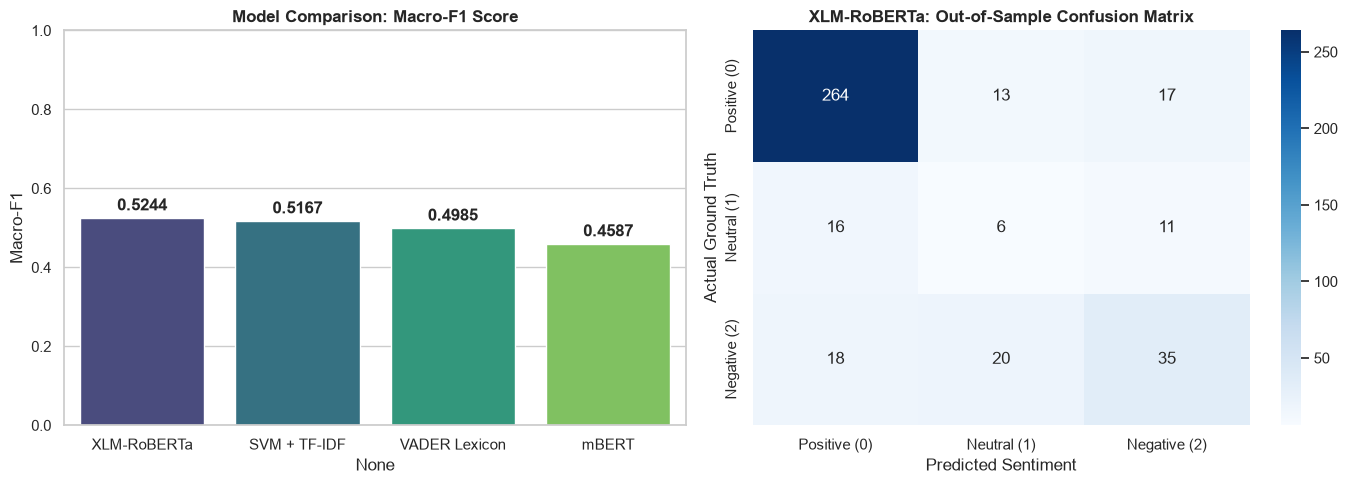

In [25]:
def get_metrics(preds, trues):                                                                                           
    p, r, f, _ = precision_recall_fscore_support(trues, preds, average='macro', zero_division=0)
    return round(p, 4), round(r, 4), round(f, 4)

results = {
    "XLM-RoBERTa": get_metrics(xlmr_preds, true_labels),                                                                 
    "mBERT": get_metrics(mbert_preds, true_labels),                                                                      
    "SVM + TF-IDF": get_metrics(svm_preds, true_labels),                                                                 
    "VADER Lexicon": get_metrics(vader_preds, true_labels)                                                               
}                                                                                                                        
                                                                                                                            
# Output the Table                                                                                                    
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Macro-Precision', 'Macro-Recall', 'Macro-F1'])
results_df = results_df.sort_values(by='Macro-F1', ascending=False)                                                      
print("\n=== STEP 8.1 & 8.2: FINAL BENCHMARK TABLE ===")
print(results_df.to_string())
results_df.to_csv("Final_Benchmark_Results.csv")
                                                                                                                            
# Plot  Charts                                                                                                     
sns.set_theme(style="whitegrid")                                                                                         
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))                                                                    
                                                                                                                            
# Bar Chart
sns.barplot(x=results_df.index, y=results_df['Macro-F1'], palette="viridis", ax=ax1)
ax1.set_title("Model Comparison: Macro-F1 Score", fontweight='bold')                                                     
ax1.set_ylabel("Macro-F1")                                                                                               
ax1.set_ylim(0, 1.0)                                                                                                     
for i, v in enumerate(results_df['Macro-F1']):                                                                           
    ax1.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')                                                    
                                                                                                                            
# Confusion Matrix for XLM-RoBERTa
cm = confusion_matrix(true_labels, xlmr_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Positive (0)', 'Neutral (1)', 'Negative (2)'],
            yticklabels=['Positive (0)', 'Neutral (1)', 'Negative (2)'], ax=ax2)
ax2.set_title("XLM-RoBERTa: Out-of-Sample Confusion Matrix", fontweight='bold')
ax2.set_xlabel("Predicted Sentiment")
ax2.set_ylabel("Actual Ground Truth")

plt.tight_layout()
plt.show()                                                                                                               


=== FINAL BENCHMARK TABLE ===
               accuracy  macro_f1  weighted_f1  f1_positive  f1_neutral  f1_negative
Model                                                                               
XLM-RoBERTa      0.7625    0.5244       0.7632       0.8919      0.1667       0.5147
SVM + TF-IDF     0.7625    0.5167       0.7470       0.8684      0.1569       0.5248
VADER Lexicon    0.6875    0.4985       0.7108       0.8293      0.2034       0.4630
mBERT            0.7175    0.4587       0.7119       0.8339      0.0000       0.5422


C:\Users\loren\AppData\Local\Temp\ipykernel_18636\291596531.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['macro_f1'], palette="viridis", ax=ax1)


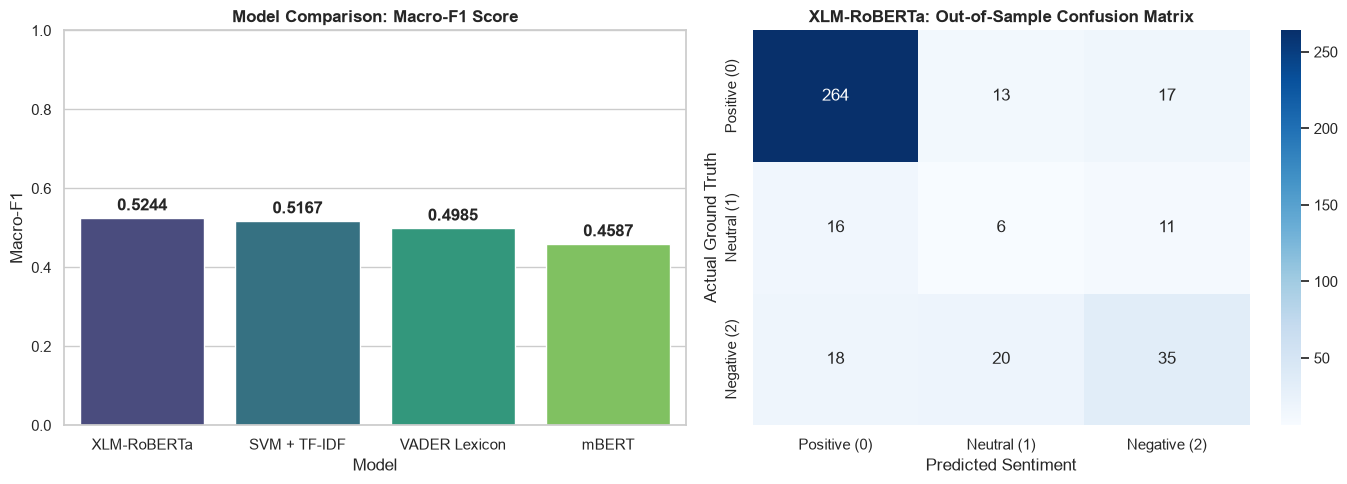

In [26]:
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support                                    
                                                                                                                            
def get_metrics(preds, trues):                                                                                           
    acc = accuracy_score(trues, preds)                                                                                   
    mac_f1 = f1_score(trues, preds, average='macro', zero_division=0)                                                    
    wt_f1 = f1_score(trues, preds, average='weighted', zero_division=0)                                                  
                                                                                                                            
    # Extract specific class F1 scores (0=Positive, 1=Neutral, 2=Negative)                                               
    _, _, f_class, _ = precision_recall_fscore_support(trues, preds, labels=[0, 1, 2], zero_division=0)                  
                                                                                                                            
    return round(acc, 4), round(mac_f1, 4), round(wt_f1, 4), round(f_class[0], 4), round(f_class[1], 4), round(f_class[2],
4)                                                                                                                         
                                                                                                                            
results = {                                                                                                              
    "XLM-RoBERTa": get_metrics(xlmr_preds, true_labels),                                                                 
    "mBERT": get_metrics(mbert_preds, true_labels),                                                                      
    "SVM + TF-IDF": get_metrics(svm_preds, true_labels),                                                                 
    "VADER Lexicon": get_metrics(vader_preds, true_labels)                                                               
}                                                                                                                        
                                                                                                                            
# 1. Output the Table                                                                                                    
cols = ['accuracy', 'macro_f1', 'weighted_f1', 'f1_positive', 'f1_neutral', 'f1_negative']                               
results_df = pd.DataFrame.from_dict(results, orient='index', columns=cols)                                               
results_df.index.name = 'Model'                                                                                          
results_df = results_df.sort_values(by='macro_f1', ascending=False)                                                      
                                                                                                                            
print("\n=== FINAL BENCHMARK TABLE ===")                                                                                 
print(results_df.to_string())                                                                                            
results_df.to_csv("Final_Benchmark_Results.csv")                                                                         
                                                                                                                            
# 2. Plot the Charts                                                                                                     
sns.set_theme(style="whitegrid")                                                                                         
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))                                                                    
                                                                                                                            
sns.barplot(x=results_df.index, y=results_df['macro_f1'], palette="viridis", ax=ax1)                                     
ax1.set_title("Model Comparison: Macro-F1 Score", fontweight='bold')                                                     
ax1.set_ylabel("Macro-F1")                                                                                               
ax1.set_ylim(0, 1.0)                                                                                                     
for i, v in enumerate(results_df['macro_f1']):                                                                           
    ax1.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')                                                    
                                                                                                                            
cm = confusion_matrix(true_labels, xlmr_preds)                                                                           
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',                                                                       
            xticklabels=['Positive (0)', 'Neutral (1)', 'Negative (2)'],                                                 
            yticklabels=['Positive (0)', 'Neutral (1)', 'Negative (2)'], ax=ax2)                                         
ax2.set_title("XLM-RoBERTa: Out-of-Sample Confusion Matrix", fontweight='bold')                                          
ax2.set_xlabel("Predicted Sentiment")                                                                                    
ax2.set_ylabel("Actual Ground Truth")                                                                                    
                                                                                                                            
plt.tight_layout()                                                                                                       
plt.show()

=== HYPERPARAMETER TUNING & VALIDATION RESULTS ===
Learning Rate  Batch Size  Best Epoch  Val Macro-F1
        2e-05          16           5        0.4385
        2e-05          32           4        0.4176
        3e-05          16           5        0.4189
        3e-05          32           5        0.4618
        5e-05          16           5        0.4558
        5e-05          32           4        0.4384


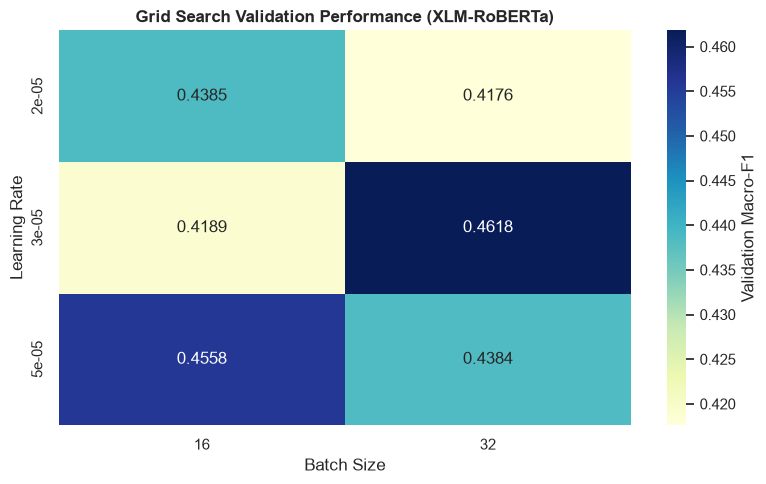

In [27]:
import pandas as pd                                                                                                      
import seaborn as sns                                                                                                    
import matplotlib.pyplot as plt                                                                                          
                                                                                                                            
# Reconstructed from your exact Step 7.4 Grid Search execution logs                                                      
tuning_results = [                                                                                                       
    {'Learning Rate': '2e-05', 'Batch Size': 16, 'Best Epoch': 5, 'Val Macro-F1': 0.4385},                               
    {'Learning Rate': '2e-05', 'Batch Size': 32, 'Best Epoch': 4, 'Val Macro-F1': 0.4176},                               
    {'Learning Rate': '3e-05', 'Batch Size': 16, 'Best Epoch': 5, 'Val Macro-F1': 0.4189},                               
    {'Learning Rate': '3e-05', 'Batch Size': 32, 'Best Epoch': 5, 'Val Macro-F1': 0.4618},                               
    {'Learning Rate': '5e-05', 'Batch Size': 16, 'Best Epoch': 5, 'Val Macro-F1': 0.4558},                               
    {'Learning Rate': '5e-05', 'Batch Size': 32, 'Best Epoch': 4, 'Val Macro-F1': 0.4384}                                
]                                                                                                                        
                                                                                                                            
tune_df = pd.DataFrame(tuning_results)                                                                                   
                                                                                                                            
print("=== HYPERPARAMETER TUNING & VALIDATION RESULTS ===")                                                              
print(tune_df.to_string(index=False))                                                                                    
tune_df.to_csv("Hyperparameter_Tuning_Results.csv", index=False)                                                         
                                                                                                                            
# 2. Plotting the Grid Search Heatmap                                                                                    
pivot_df = tune_df.pivot(index='Learning Rate', columns='Batch Size', values='Val Macro-F1')                             
                                                                                                                            
plt.figure(figsize=(8, 5))                                                                                               
sns.heatmap(pivot_df, annot=True, fmt=".4f", cmap="YlGnBu", cbar_kws={'label': 'Validation Macro-F1'})                   
plt.title("Grid Search Validation Performance (XLM-RoBERTa)", fontweight='bold')                                         
plt.xlabel("Batch Size")                                                                                                 
plt.ylabel("Learning Rate")                                                                                              
plt.tight_layout()                                                                                                       
plt.show()

## Statistical Model Comparison

In [ ]:
# Evaluates statistical significance between XLM-RoBERTa and all Baselines                                               
# Equation: X^2 = (b - c)^2 / (b + c)  

In [28]:
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar   

In [30]:
def run_mcnemar_test(baseline_name, baseline_preds, alpha=0.05):                                                         
    """Calculates exactly b and c as defined in the manuscript methodology."""                                           
                                                                                                                            
    # b: XLM-R was correct, Baseline was incorrect                                                                       
    # c: Baseline was correct, XLM-R was incorrect                                                                       
    b = 0                                                                                                                
    c = 0                                                                                                                
    both_correct = 0                                                                                                     
    both_incorrect = 0                                                                                                   
                                                                                                                            
    for true_val, xlmr_val, base_val in zip(true_labels, xlmr_preds, baseline_preds):                                    
        if xlmr_val == true_val and base_val != true_val:                                                                
            b += 1                                                                                                       
        elif xlmr_val != true_val and base_val == true_val:                                                              
            c += 1                                                                                                       
        elif xlmr_val == true_val and base_val == true_val:                                                              
            both_correct += 1                                                                                            
        else:                                                                                                            
            both_incorrect += 1                                                                                          
                                                                                                                            
    # Format 2x2 Contingency Table for statsmodels                                                                
    table = [[both_correct, c],                                                                                          
                [b, both_incorrect]]                                                                                        
                                                                                                                            
    # exact=False maps perfectly to your asymptotic Chi-Square formula                                                   
    # correction=False disables Yates' continuity correction to match your raw equation                                  
    result = mcnemar(table, exact=False, correction=False)                                                               
                                                                                                                            
    is_significant = "Yes (Reject Null)" if result.pvalue < alpha else "No"                                              
                                                                                                                            
    return {                                                                                                             
        'Baseline': baseline_name,                                                                                       
        'b (XLM-R Correct Only)': b,                                                                                     
        'c (Baseline Correct Only)': c,                                                                                  
        'Chi-Square (χ²)': round(result.statistic, 4),                                                                   
        'p-value': f"{result.pvalue:.4e}",                                                                               
        'Statistically Significant (α=0.05)': is_significant                                                             
    }                                                                                                                    
                                                                                                                            
                                                                                      
mcnemar_results = [                                                                                                      
    run_mcnemar_test("VADER Lexicon", vader_preds),                                                                      
    run_mcnemar_test("SVM + TF-IDF", svm_preds),                                                                         
    run_mcnemar_test("mBERT", mbert_preds)                                                                               
]                                                                                                                        
                                                                                                                            
mcnemar_df = pd.DataFrame(mcnemar_results)                                                                               
                                                                                                                          
print("MCNEMAR'S TEST RESULTS:")                                                                        
print(mcnemar_df.to_string(index=False))                                                                                 
mcnemar_df.to_csv("McNemar_Test_Results.csv", index=False)

MCNEMAR'S TEST RESULTS:
     Baseline  b (XLM-R Correct Only)  c (Baseline Correct Only)  Chi-Square (χ²)    p-value Statistically Significant (α=0.05)
VADER Lexicon                      64                         34           9.1837 2.4418e-03                  Yes (Reject Null)
 SVM + TF-IDF                      33                         33           0.0000 1.0000e+00                                 No
        mBERT                      54                         36           3.6000 5.7780e-02                                 No
